In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sakshibhosale1904/construction-cost-overrun-prediction-dataset/cost_prediction.csv


In [2]:
import pandas as pd

# Load the dataset
file_path = "/kaggle/input/datasets/sakshibhosale1904/construction-cost-overrun-prediction-dataset/cost_prediction.csv"

df = pd.read_csv(file_path)

# Display basic information
print("Dataset loaded successfully!")
print("Shape:", df.shape)

# Show first 5 rows
display(df.head())

# Show column names
print("\nColumns:")
print(df.columns.tolist())

# Check data types and missing values
print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset loaded successfully!
Shape: (1000, 7)


,Project_ID,MaterialCost,LaborCost,EquipmentCost,Budget,ActualCost,Overrun
0,P0001,2484265,7864467,4684875,25080668,15033607,No
1,P0002,6962781,5209137,4189739,29236617,16361657,No
2,P0003,4904797,2305692,166463,10644034,7376952,No
3,P0004,4309683,7687790,299935,45294222,12297408,No
4,P0005,7066467,837588,4708256,11716877,12612311,Yes



Columns:
['Project_ID', 'MaterialCost', 'LaborCost', 'EquipmentCost', 'Budget', 'ActualCost', 'Overrun']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Project_ID     1000 non-null   object
 1   MaterialCost   1000 non-null   int64 
 2   LaborCost      1000 non-null   int64 
 3   EquipmentCost  1000 non-null   int64 
 4   Budget         1000 non-null   int64 
 5   ActualCost     1000 non-null   int64 
 6   Overrun        1000 non-null   object
dtypes: int64(5), object(2)
memory usage: 54.8+ KB

Missing Values:
Project_ID       0
MaterialCost     0
LaborCost        0
EquipmentCost    0
Budget           0
ActualCost       0
Overrun          0
dtype: int64


In [3]:
print("Overrun Distribution:")
print(df["Overrun"].value_counts())

print("\nOverrun Percentage:")
print(df["Overrun"].value_counts(normalize=True) * 100)

Overrun Distribution:
Overrun
No     851
Yes    149
Name: count, dtype: int64

Overrun Percentage:
Overrun
No     85.1
Yes    14.9
Name: proportion, dtype: float64


In [4]:
df["Calculated_Overrun"] = df["ActualCost"] > df["Budget"]

print(pd.crosstab(df["Overrun"], df["Calculated_Overrun"]))

Calculated_Overrun  False  True 
Overrun                         
No                    851      0
Yes                     0    149


In [5]:
df["Cost_Difference"] = df["ActualCost"] - df["Budget"]

print(df[["Budget", "ActualCost", "Cost_Difference", "Overrun"]].head(10))

     Budget  ActualCost  Cost_Difference Overrun
0  25080668    15033607        -10047061      No
1  29236617    16361657        -12874960      No
2  10644034     7376952         -3267082      No
3  45294222    12297408        -32996814      No
4  11716877    12612311           895434     Yes
5  33969717    14236827        -19732890      No
6  34717447    11423363        -23294084      No
7  39350404    16984418        -22365986      No
8  47719333     6529348        -41189985      No
9  45362735     7374113        -37988622      No


In [7]:
# Select features without data leakage
features = [
    "MaterialCost",
    "LaborCost",
    "EquipmentCost",
    "Budget"
]

X = df[features]

# Convert target to 0/1
y = df["Overrun"].map({
    "No": 0,
    "Yes": 1
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print(y.value_counts(normalize=True) * 100)

Feature shape: (1000, 4)
Target shape: (1000,)

Features:
   MaterialCost  LaborCost  EquipmentCost    Budget
0       2484265    7864467        4684875  25080668
1       6962781    5209137        4189739  29236617
2       4904797    2305692         166463  10644034
3       4309683    7687790         299935  45294222
4       7066467     837588        4708256  11716877

Target distribution:
Overrun
0    851
1    149
Name: count, dtype: int64

Target percentages:
Overrun
0    85.1
1    14.9
Name: proportion, dtype: float64


In [8]:
# Correlation analysis
correlation = df[
    ["MaterialCost", "LaborCost", "EquipmentCost", "Budget"]
].corr()

print(correlation)

               MaterialCost  LaborCost  EquipmentCost    Budget
MaterialCost       1.000000   0.017589       0.023918  0.020508
LaborCost          0.017589   1.000000      -0.002704  0.030380
EquipmentCost      0.023918  -0.002704       1.000000  0.028231
Budget             0.020508   0.030380       0.028231  1.000000


Training samples: 800
Testing samples: 200

MODEL PERFORMANCE
Accuracy: 0.9850
Accuracy: 98.50%

Classification Report:
              precision    recall  f1-score   support

  No Overrun       0.98      1.00      0.99       170
     Overrun       1.00      0.90      0.95        30

    accuracy                           0.98       200
   macro avg       0.99      0.95      0.97       200
weighted avg       0.99      0.98      0.98       200


Confusion Matrix:
[[170   0]
 [  3  27]]


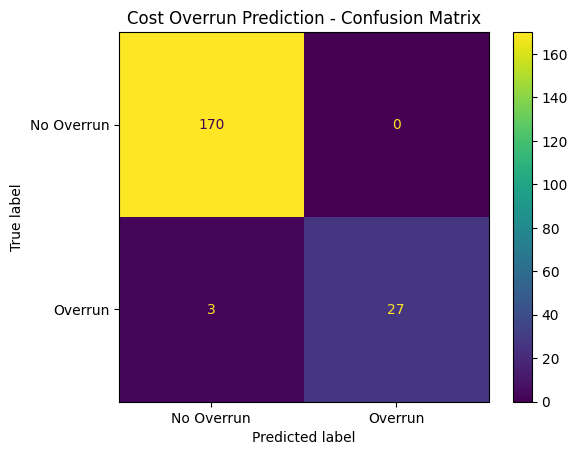


Feature Importance:
         Feature  Importance
3         Budget    0.788585
0   MaterialCost    0.091615
1      LaborCost    0.081112
2  EquipmentCost    0.038689


In [9]:
# ============================================
# COST OVERRUN PREDICTION - RANDOM FOREST
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. Select features
# --------------------------------------------

features = [
    "MaterialCost",
    "LaborCost",
    "EquipmentCost",
    "Budget"
]

X = df[features]

# Target: No = 0, Yes = 1
y = df["Overrun"].map({
    "No": 0,
    "Yes": 1
})

# --------------------------------------------
# 2. Train-Test Split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# --------------------------------------------
# 3. Train Random Forest
# --------------------------------------------

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# --------------------------------------------
# 4. Make Predictions
# --------------------------------------------

y_pred = model.predict(X_test)

# --------------------------------------------
# 5. Evaluate Model
# --------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Overrun", "Overrun"]
))

# --------------------------------------------
# 6. Confusion Matrix
# --------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Overrun", "Overrun"]
)

disp.plot()
plt.title("Cost Overrun Prediction - Confusion Matrix")
plt.show()

# --------------------------------------------
# 7. Feature Importance
# --------------------------------------------

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 40)

for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(
        f"{metric.upper():10}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

5-FOLD CROSS-VALIDATION RESULTS
ACCURACY  : 0.9720 ± 0.0144
PRECISION : 0.9342 ± 0.0442
RECALL    : 0.8720 ± 0.0628
F1        : 0.9017 ± 0.0524
ROC_AUC   : 0.9937 ± 0.0073


In [12]:
# Display Cross-Validation Results
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 40)

for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric.upper():10s}: {scores.mean():.4f} ± {scores.std():.4f}")

5-FOLD CROSS-VALIDATION RESULTS
ACCURACY  : 0.9720 ± 0.0144
PRECISION : 0.9342 ± 0.0442
RECALL    : 0.8720 ± 0.0628
F1        : 0.9017 ± 0.0524
ROC_AUC   : 0.9937 ± 0.0073


In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 50)

results = {}

for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    mean = scores.mean()
    std = scores.std()

    results[metric] = mean

    print(
        f"{metric.upper():10s}: "
        f"{mean:.4f} ± {std:.4f}"
    )

5-FOLD CROSS-VALIDATION RESULTS
ACCURACY  : 0.9720 ± 0.0144
PRECISION : 0.9342 ± 0.0442
RECALL    : 0.8720 ± 0.0628
F1        : 0.9017 ± 0.0524
ROC_AUC   : 0.9937 ± 0.0073


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("FINAL TEST SET RESULTS")
print("=" * 40)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

FINAL TEST SET RESULTS
Accuracy : 0.9850
Precision: 1.0000
Recall   : 0.9000
F1 Score : 0.9474
ROC-AUC  : 0.9986


In [16]:
import joblib

joblib.dump(model, "cost_prediction_model.joblib")

print("Model saved successfully!")

Model saved successfully!


In [17]:
import json

feature_info = {
    "features": list(X.columns),
    "target": y.name,
    "model_type": type(model).__name__
}

with open("feature_info.json", "w") as f:
    json.dump(feature_info, f, indent=4)

print("Feature information saved successfully!")

Feature information saved successfully!


In [18]:
import json

feature_info = {
    "features": list(X.columns),
    "target": y.name,
    "model_type": type(model).__name__
}

with open("feature_info.json", "w") as f:
    json.dump(feature_info, f, indent=4)

print("✅ Feature information saved successfully!")

✅ Feature information saved successfully!


In [19]:
import os

print("Files created:")
print("cost_prediction_model.joblib :", os.path.exists("cost_prediction_model.joblib"))
print("feature_info.json            :", os.path.exists("feature_info.json"))

Files created:
cost_prediction_model.joblib : True
feature_info.json            : True
